In [ ]:
# SQL 缺失值检查
# select 
# (sum(order_approved_at is null) / count(*)) * 100 as approved_null_rate,
# (sum(order_delivered_carrier_date is null) / count(*)) * 100 as carrier_null_rate,
# (sum(order_delivered_customer_date is null) / count(*)) * 100 as delivered_null_rate
# from orders;

# select 
# (sum(product_category_name is null) / count(*)) * 100 as category_null_rate
# from products;

# select
# (sum(review_comment_title is null) / count(*)) * 100 as title_null_rate,
# (sum(review_comment_message is null) / count(*)) * 100 as message_null_rate
# from reviews;

In [ ]:
# SQL 重复值检查
# select order_id, count(*) as cnt from orders
# group by order_id
# having cnt > 1;

# select customer_id, count(*) as cnt from customers
# group by customer_id
# having cnt > 1;

# select customer_unique_id, count(*) as cnt from customers
# group by customer_unique_id
# having cnt > 1;

In [ ]:
# SQL 创建订单分析表
# create table orders_clean as

# 避免 payment_value 重复计入
# with payment_total as(
# 	select order_id, sum(payment_value) as payment_value from payments
#     group by order_id),
# 	review_avg as(
# 	select order_id, round(avg(review_score), 1) as review_score from reviews
#     group by order_id)

# select 
# o.order_id,
# c.customer_unique_id,
# o.order_purchase_timestamp,
# o.order_delivered_customer_date,
# o.order_estimated_delivery_date,
# p.payment_value,
# r.review_score
# from orders o

# left join customers c on o.customer_id = c.customer_id
# left join payment_total p on o.order_id = p.order_id
# left join review_avg r on o.order_id = r.order_id

# where o.order_status = 'delivered';

# select * from orders_clean limit 10;

# select count(*) as total_orders from orders_clean;

# select order_id, count(*) from orders_clean
# group by order_id
# having count(*) > 1;

In [ ]:
# SQL 创建商品分析表
# create table items_clean as

# select
# oi.order_id,
# oi.order_item_id,
# oi.product_id,
# oi.seller_id,
# p.product_category_name,
# oi.price,
# oi.freight_value,
# s.seller_city,
# s.seller_state
# from order_items oi

# left join products p on oi.product_id = p.product_id
# left join sellers s on oi.seller_id = s.seller_id;

# select * from items_clean limit 10;

# select count(*) from items_clean;

# select order_id, order_item_id, count(*) from items_clean
# group by order_id, order_item_id
# having count(*) > 1;

In [1]:
# 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表样式
sns.set_theme(style = "whitegrid")
pd.set_option("display.float_format", lambda 数值: f"{数值:,.2f}")
plt.rcParams["axes.titleweight"] = "bold"

# 解决中文显示问题
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False # 解决负号显示问题

In [2]:
orders_clean = pd.read_csv("orders_clean.csv",
                    parse_dates = [
                        "order_purchase_timestamp",
                        "order_delivered_customer_date",
                        "order_estimated_delivery_date"
                    ])
items_clean = pd.read_csv("items_clean.csv")

print(f"orders_clean shape:{orders_clean.shape}")
print(f"items_clean shape:{items_clean.shape}")

orders_clean shape:(96478, 7)
items_clean shape:(112650, 9)


In [3]:
orders_clean.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,72.19,5.00
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,259.83,4.00
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,25.78,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,218.04,5.00


In [4]:
items_clean.head()

,order_id,order_item_id,product_id,seller_id,product_category_name,price,freight_value,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,cool_stuff,58.90,13.29,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,239.90,19.93,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,199.00,17.87,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,perfumaria,12.99,12.79,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,199.90,18.14,loanda,PR


In [5]:
orders = orders_clean.copy()
items = items_clean.copy()

In [6]:
# 按月进行统计
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
orders.groupby("order_month")["payment_value"].sum()
orders[["order_id", "customer_unique_id", "order_month", "payment_value"]].head()

,order_id,customer_unique_id,order_month,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-01,72.19
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-01,259.83
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-01,216.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-01,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-01,218.04


In [7]:
# 计算月度GMV、订单数、活跃用户、新增用户和客单价
monthly_growth = (orders.groupby("order_month", as_index = False)
                  .agg(
                      gmv = ("payment_value", "sum"),
                      orders = ("order_id", "nunique"),
                      active_users = ("customer_unique_id", "nunique")
                  ).sort_values("order_month")
                 )

first_purchase_month = (orders.groupby("customer_unique_id", as_index = False)
                        .agg(first_purchase_month = ("order_month", "min"))
                       )

monthly_new_users = (first_purchase_month.groupby("first_purchase_month", as_index = False)
                     .agg(new_users = ("customer_unique_id", "nunique"))
                     .rename(columns = {"first_purchase_month":"order_month"})
                    )

monthly_growth = monthly_growth.merge(monthly_new_users, 
                                      on = "order_month", 
                                      how = "left")
monthly_growth["new_users"] = monthly_growth["new_users"].fillna(0).astype(int)
monthly_growth["aov"] = monthly_growth["gmv"] / monthly_growth["orders"]
monthly_growth["purchase_frequency"] = monthly_growth["orders"] / monthly_growth["active_users"]
monthly_growth["gmv_growth_rate"] = monthly_growth["gmv"].pct_change() * 100

monthly_growth

,order_month,gmv,orders,active_users,new_users,aov,purchase_frequency,gmv_growth_rate
0,2016-09-01,0.00,1,1,1,0.00,1.00,NaN
1,2016-10-01,"46,566.71",265,262,262,175.72,1.01,inf
2,2016-12-01,19.62,1,1,1,19.62,1.00,-99.96
3,2017-01-01,"127,545.67",750,718,717,170.06,1.04,"649,979.87"
4,2017-02-01,"271,298.65",1653,1630,1628,164.13,1.01,112.71
5,2017-03-01,"414,369.39",2546,2508,2503,162.75,1.02,52.74
6,2017-04-01,"390,952.18",2303,2274,2256,169.76,1.01,-5.65
7,2017-05-01,"567,066.73",3546,3479,3451,159.92,1.02,45.05
8,2017-06-01,"490,225.60",3135,3076,3037,156.37,1.02,-13.55
9,2017-07-01,"566,403.93",3872,3802,3752,146.28,1.02,15.54


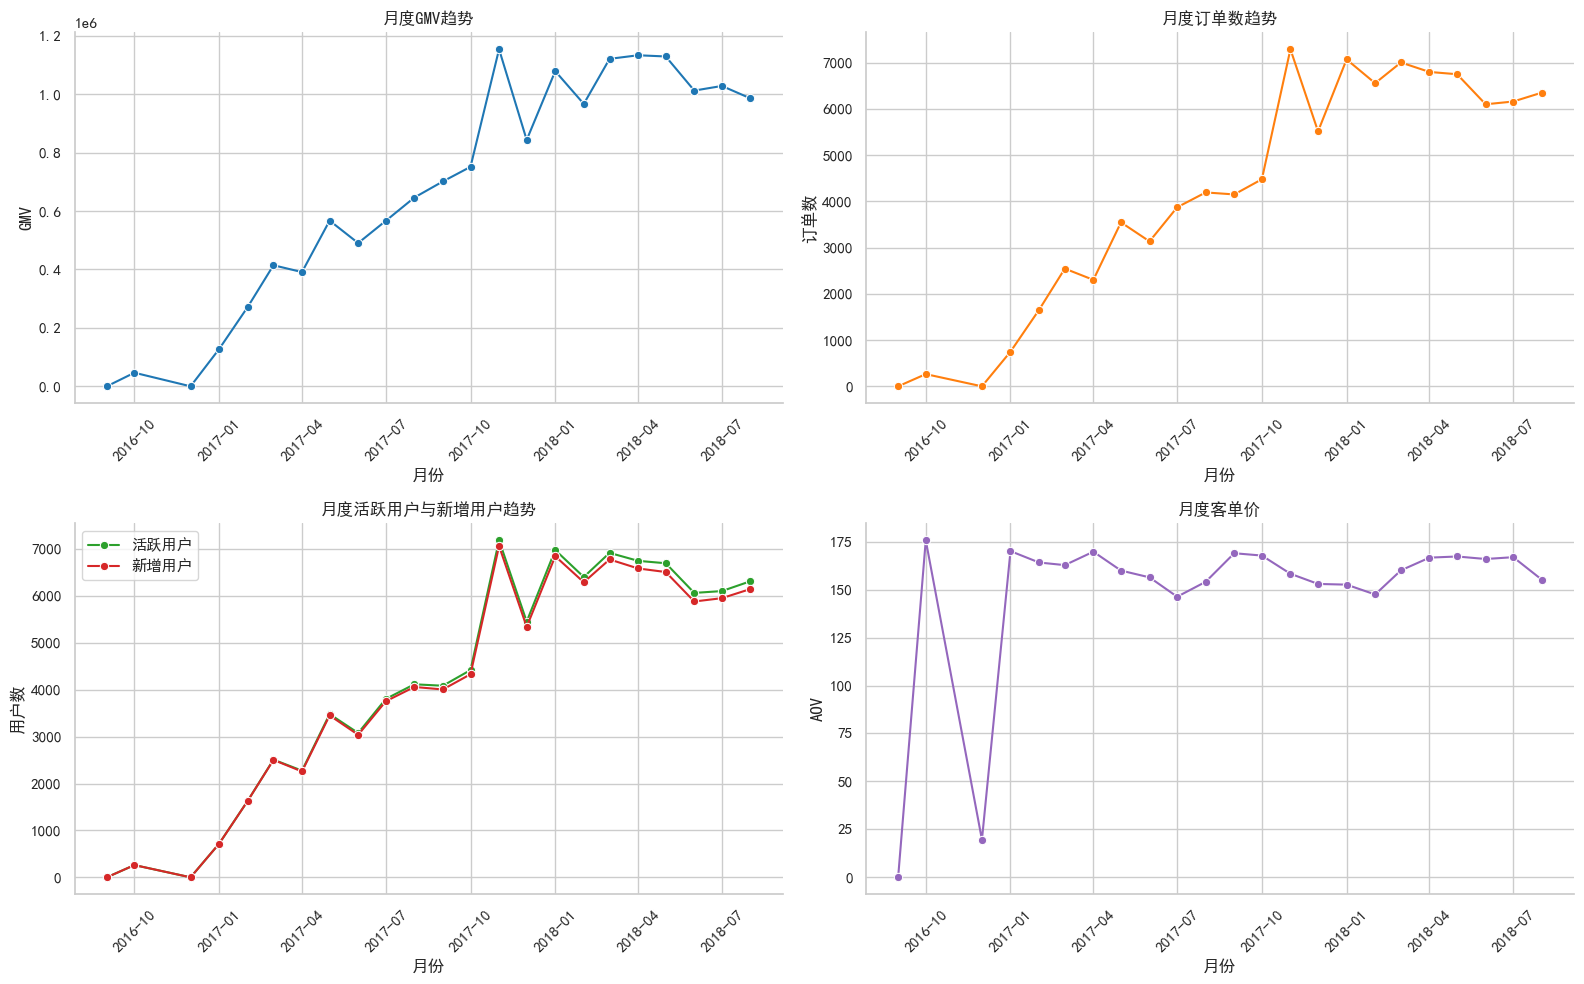

In [8]:
# 绘制平台增长核心指标趋势图
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

sns.lineplot(
    data = monthly_growth,
    x = "order_month",
    y = "gmv",
    marker = "o",
    ax = axes[0, 0],
    color = "#1f77b4")
axes[0, 0].set_title("月度GMV趋势")
axes[0, 0].set_xlabel("月份")
axes[0, 0].set_ylabel("GMV")

sns.lineplot(
    data = monthly_growth,
    x = "order_month",
    y = "orders",
    marker = "o",
    ax = axes[0, 1],
    color = "#ff7f0e")
axes[0, 1].set_title("月度订单数趋势")
axes[0, 1].set_xlabel("月份")
axes[0, 1].set_ylabel("订单数")

sns.lineplot(
    data = monthly_growth,
    x = "order_month",
    y = "active_users",
    marker = "o",
    label = "活跃用户",
    ax = axes[1, 0],
    color = "#2ca02c")
sns.lineplot(
    data = monthly_growth,
    x = "order_month",
    y = "new_users",
    marker = "o",
    label = "新增用户",
    ax = axes[1, 0],
    color = "#d62728")
axes[1, 0].set_title("月度活跃用户与新增用户趋势")
axes[1, 0].set_xlabel("月份")
axes[1, 0].set_ylabel("用户数")

sns.lineplot(
    data = monthly_growth,
    x = "order_month",
    y = "aov",
    marker = "o",
    ax = axes[1, 1],
    color = "#9467bd")
axes[1, 1].set_title("月度客单价")
axes[1, 1].set_xlabel("月份")
axes[1, 1].set_ylabel("AOV")

for axis in axes.flat:
    axis.tick_params(axis = "x", rotation = 45)
    axis.spines[["top", "right"]].set_visible(False)
    
plt.tight_layout()
plt.show()

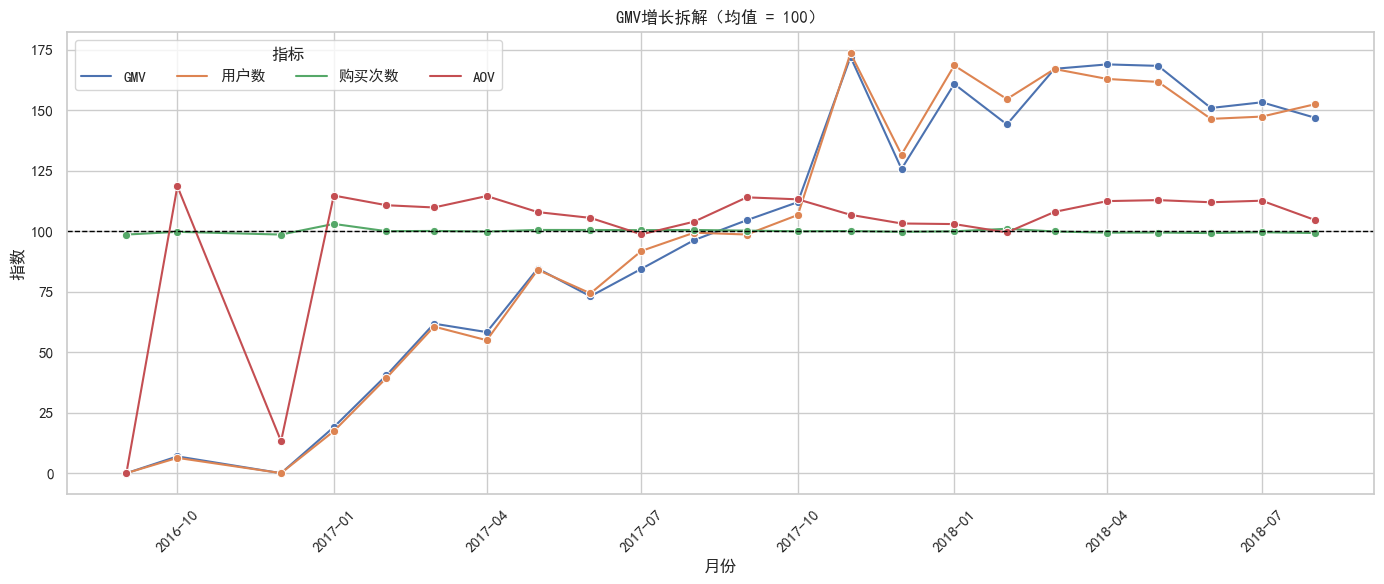

,order_month,gmv,active_users,purchase_frequency,aov,gmv_index,active_users_index,purchase_frequency_index,aov_index
0,2016-09-01,0.00,1,1.00,0.00,0.00,0.02,98.63,0.00
1,2016-10-01,"46,566.71",262,1.01,175.72,6.94,6.33,99.76,118.57
2,2016-12-01,19.62,1,1.00,19.62,0.00,0.02,98.63,13.24
3,2017-01-01,"127,545.67",718,1.04,170.06,19.02,17.35,103.02,114.75
4,2017-02-01,"271,298.65",1630,1.01,164.13,40.46,39.38,100.02,110.75


In [9]:
# 将GMV增长拆解为用户数、购买频次和客单价
growth_decomposition = monthly_growth[["order_month", "gmv", "active_users", "purchase_frequency", "aov"]].copy()

for metric in ["gmv", "active_users", "purchase_frequency", "aov"]:
    growth_decomposition[f"{metric}_index"] = (growth_decomposition[metric] / growth_decomposition[metric].mean() * 100)

decomposition_plot = growth_decomposition.melt(id_vars = "order_month",
                                               value_vars = ["gmv_index", "active_users_index", "purchase_frequency_index", "aov_index"],
                                               var_name = "metric",
                                               value_name = "index")

decomposition_plot["metric"] = decomposition_plot["metric"].map({"gmv_index":"GMV",
                                                                 "active_users_index":"用户数",
                                                                 "purchase_frequency_index":"购买次数",
                                                                 "aov_index":"AOV"})

plt.figure(figsize = (14, 6))
sns.lineplot(data = decomposition_plot,
             x = "order_month",
             y = "index",
             hue = "metric",
             marker = "o")
plt.axhline(100, color = "black", linestyle = "--", linewidth = 1)
plt.title("GMV增长拆解（均值 = 100）")
plt.xlabel("月份")
plt.ylabel("指数")
plt.xticks(rotation = 45)
plt.legend(title = "指标", ncol = 4)
plt.tight_layout()
plt.show()
growth_decomposition.head()

In [10]:
# 构建用于留存和复购分析的用户订单表
customer_orders = orders[["order_id", "customer_unique_id", "order_purchase_timestamp", "order_month", "payment_value"]].copy()
customer_orders["cohort_month"] = (customer_orders.groupby("customer_unique_id")["order_month"].transform("min"))
customer_orders["period_number"] = ((customer_orders["order_month"].dt.year - customer_orders["cohort_month"].dt.year) * 12 
                                   + customer_orders["order_month"].dt.month - customer_orders["cohort_month"].dt.month)
customer_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_month,payment_value,cohort_month,period_number
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017-09-01,72.19,2017-09-01,0
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017-04-01,259.83,2017-04-01,0
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018-01-01,216.87,2018-01-01,0
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018-08-01,25.78,2018-08-01,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017-02-01,218.04,2017-02-01,0


In [11]:
# 计算首购Cohort的第0月至第12月留存矩阵
cohort_users = (customer_orders.loc[customer_orders["period_number"].between(0, 12)]
                .groupby(["cohort_month", "period_number"])["customer_unique_id"].nunique()
                .unstack(fill_value = 0)
                .reindex(columns = range(13), fill_value = 0))
cohort_sizes = cohort_users[0]
retention_matrix = cohort_users.div(cohort_sizes, axis = 0).mul(100)
retention_matrix.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2016-09-01,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10-01,100.00,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00
2016-12-01,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01-01,100.00,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70
2017-02-01,100.00,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12


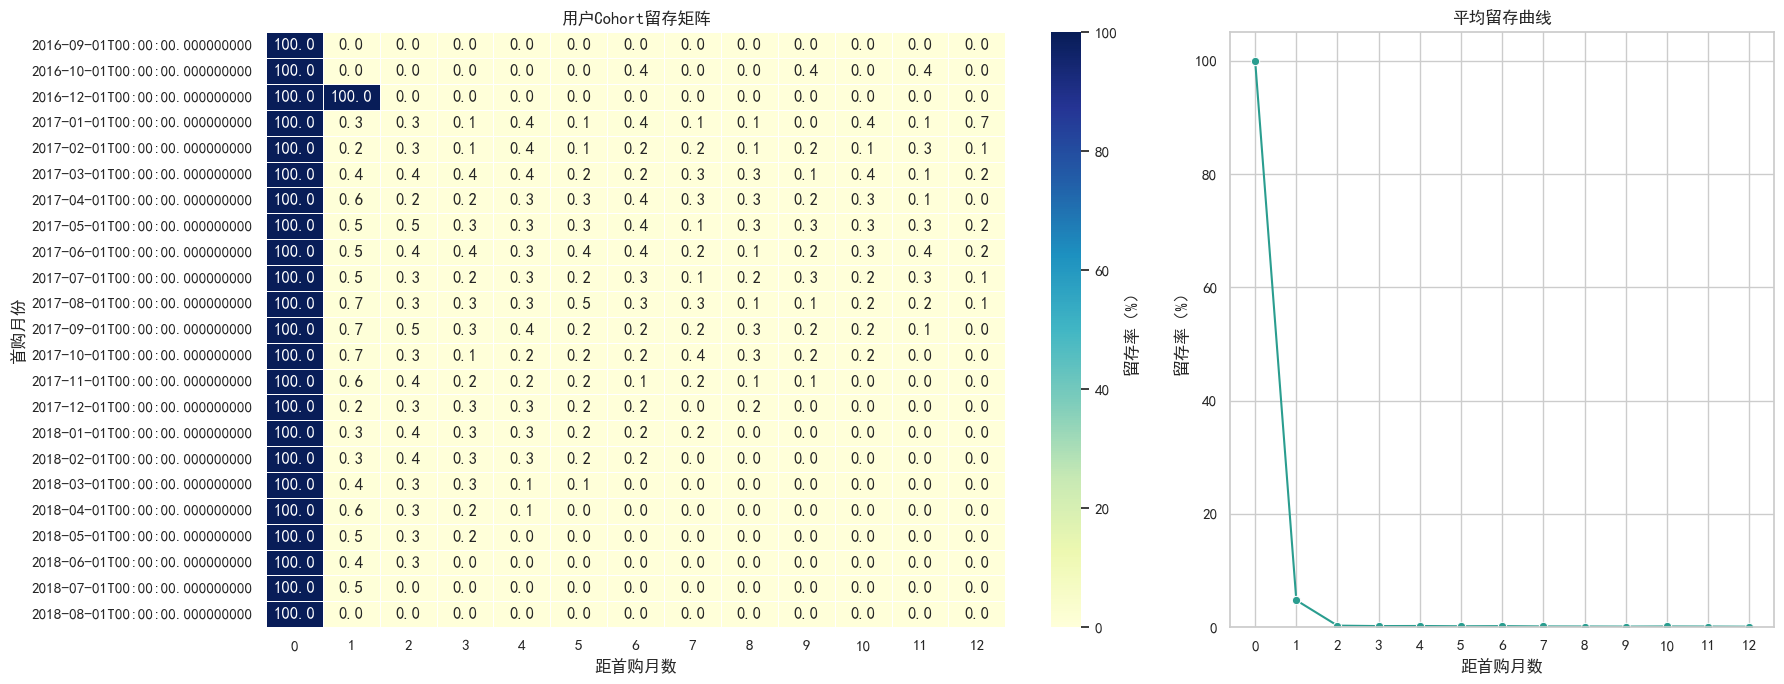

,month_number,retention_rate
0,0,100.00
1,1,4.74
2,2,0.26
3,3,0.19
4,4,0.20
5,5,0.15
6,6,0.18
7,7,0.12
8,8,0.11
9,9,0.09


In [12]:
# 绘制Cohort留存热力图和平均留存曲线
retention_curve = retention_matrix.mean(axis = 0, skipna = True).reset_index()
retention_curve.columns = ["month_number", "retention_rate"]

fig, axes = plt.subplots(1, 2, figsize = (18, 7), gridspec_kw = {"width_ratios":[1.7, 1]})

sns.heatmap(retention_matrix, 
            annot = True,
            fmt = ".1f",
            cmap = "YlGnBu",
            vmin = 0,
            vmax = 100,
            linewidths = 0.5,
            cbar_kws = {"label":"留存率（%）"},
            ax = axes[0])
axes[0].set_title("用户Cohort留存矩阵")
axes[0].set_xlabel("距首购月数")
axes[0].set_ylabel("首购月份")

sns.lineplot(data = retention_curve,
             x = "month_number",
             y = "retention_rate",
             marker = "o",
             color = "#2a9d8f",
             ax = axes[1])
axes[1].set_title("平均留存曲线")
axes[1].set_xlabel("距首购月数")
axes[1].set_ylabel("留存率（%）")
axes[1].set_xticks(range(13))
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()
display(retention_curve)

In [13]:
# 计算复购率和用户生命周期指标
customer_order_summary = (customer_orders.groupby("customer_unique_id", as_index = False)
                          .agg(
                              purchase_count = ("order_id", "nunique"),
                              first_purchase_date = ("order_purchase_timestamp", "min"),
                              last_purchase_date = ("order_purchase_timestamp", "max")
                          )
                         )
customer_order_summary["生命周期天数"] = (customer_order_summary["last_purchase_date"] - customer_order_summary["first_purchase_date"]).dt.days
repurchase_summary = pd.DataFrame({"指标": ["二购率", "三购率", "平均购买次数"],
                                   "数值": [
                                       (customer_order_summary["purchase_count"] >= 2).mean() * 100,
                                       (customer_order_summary['purchase_count'] >= 3).mean() * 100,
                                       customer_order_summary['purchase_count'].mean()]
                                  })
display(repurchase_summary)
display(customer_order_summary["生命周期天数"].describe().to_frame("生命周期天数"))

,指标,数值
0,二购率,3.00
1,三购率,0.24
2,平均购买次数,1.03


,生命周期天数
count,"93,358.00"
mean,2.63
std,24.96
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,633.00


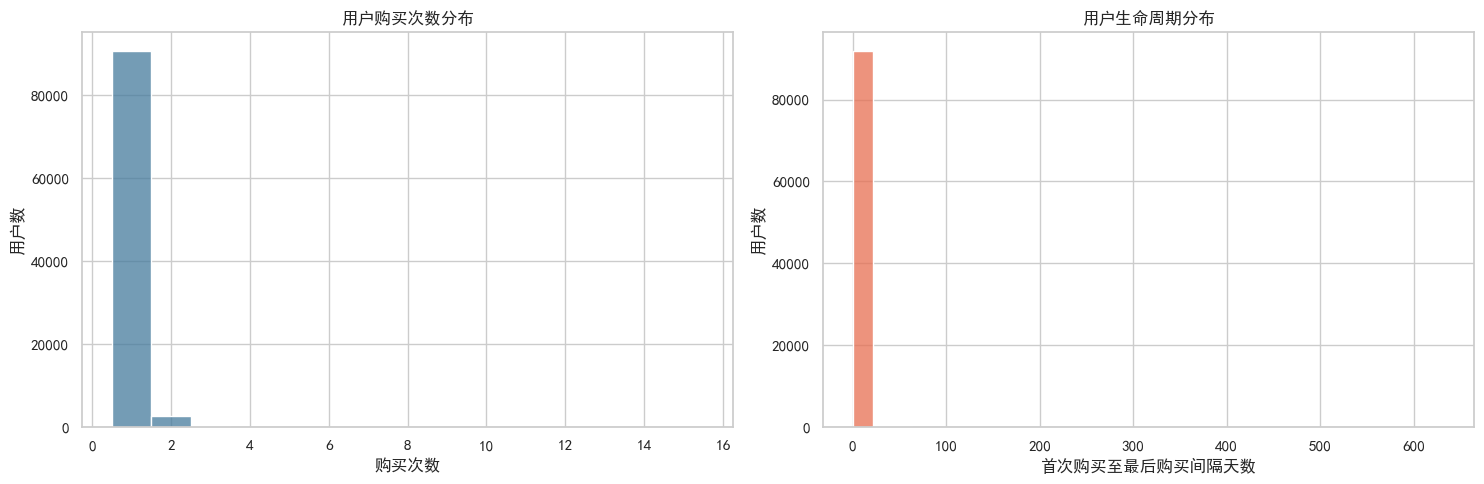

In [14]:
# 绘制购买次数和用户生命周期分布
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

sns.histplot(data = customer_order_summary, 
             x = "purchase_count", 
             discrete = True, 
             ax = axes[0], 
             color = "#457b9d")
axes[0].set_title("用户购买次数分布")
axes[0].set_xlabel("购买次数")
axes[0].set_ylabel("用户数")

sns.histplot(data = customer_order_summary, 
             x = "生命周期天数", 
             bins = 30, 
             ax = axes[1], 
             color = "#e76f51")
axes[1].set_title("用户生命周期分布")
axes[1].set_xlabel("首次购买至最后购买间隔天数")
axes[1].set_ylabel("用户数")
plt.tight_layout()
plt.show()

In [15]:
# 计算用户层面的Recency、Frequency和Monetary指标
analysis_date = customer_orders["order_purchase_timestamp"].max() + pd.Timedelta(days = 1)
rfm = (customer_orders.groupby("customer_unique_id", as_index = False)
       .agg(
           last_purchase_date = ("order_purchase_timestamp", "max"),
           frequency = ("order_id", "nunique"),
           monetary = ("payment_value", "sum")
       )
      )
rfm["recency"] = (analysis_date - rfm["last_purchase_date"]).dt.days
rfm = rfm[["customer_unique_id", "recency", "frequency", "monetary"]]
rfm["r_score"] = pd.qcut(rfm["recency"].rank(method = "first"), q = 5, labels = [5, 4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method = "first"), q = 5, labels = [1, 2, 3, 4, 5]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method = "first"), q = 5, labels = [1, 2, 3, 4, 5]).astype(int)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]
rfm.head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,6
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,7


In [16]:
# 按业务规则进行RFM分层并汇总用户价值
rfm["segment"] = "其他活跃用户"
rfm.loc[(rfm["r_score"] >= 4) & (rfm["f_score"] >= 4) & (rfm["m_score"] >= 4), "segment"] = "高价值用户"
rfm.loc[(rfm["segment"].eq("其他活跃用户")) & (rfm["r_score"] >= 4) & (rfm["f_score"] >= 3) & (rfm["m_score"] >= 3), "segment"] = "潜力用户"
rfm.loc[(rfm["segment"].eq("其他活跃用户")) & (rfm["recency"] <= 30) & (rfm["frequency"] == 1), "segment"] = "新增用户"
rfm.loc[rfm["recency"] > 180, "segment"] = "沉睡用户"
rfm.loc[(rfm["segment"].eq("其他活跃用户")) & (rfm["recency"] > 90) & (rfm["frequency"] >= 2), "segment"] = "流失风险用户"
segment_order = ["高价值用户", "潜力用户", "新增用户", "流失风险用户", "沉睡用户", "其他活跃用户"]

segment_summary = (rfm.groupby("segment", as_index = False)
                   .agg(
                       users = ("customer_unique_id", "nunique"),
                       orders = ("frequency", "sum"),
                       gmv = ("monetary", "sum"),
                       avg_recency = ("recency", "mean"),
                       avg_frequency = ("frequency", "mean"),
                       avg_monetary = ("monetary", "mean")
                   )
                  )

segment_summary["user_share"] = segment_summary["users"] / segment_summary["users"].sum() * 100
segment_summary["order_share"] = segment_summary["orders"] / segment_summary["orders"].sum() * 100
segment_summary["gmv_share"] = segment_summary["gmv"] / segment_summary["gmv"].sum() * 100
segment_summary["segment"] = pd.Categorical(segment_summary['segment'], categories = segment_order, ordered = True)
segment_summary = segment_summary.sort_values("segment")
display(segment_summary)

,segment,users,orders,gmv,avg_recency,avg_frequency,avg_monetary,user_share,order_share,gmv_share
5,高价值用户,6451,7619,"2,014,449.43",90.55,1.18,312.27,6.91,7.90,13.06
4,潜力用户,7398,7547,"1,399,090.24",90.99,1.02,189.12,7.92,7.82,9.07
1,新增用户,4329,4329,"505,269.55",18.13,1.00,116.72,4.64,4.49,3.28
3,流失风险用户,66,137,"10,026.09",150.82,2.08,151.91,0.07,0.14,0.07
2,沉睡用户,55252,56948,"8,969,294.00",338.50,1.03,162.33,59.18,59.03,58.16
0,其他活跃用户,19862,19898,"2,524,332.46",109.01,1.00,127.09,21.28,20.62,16.37


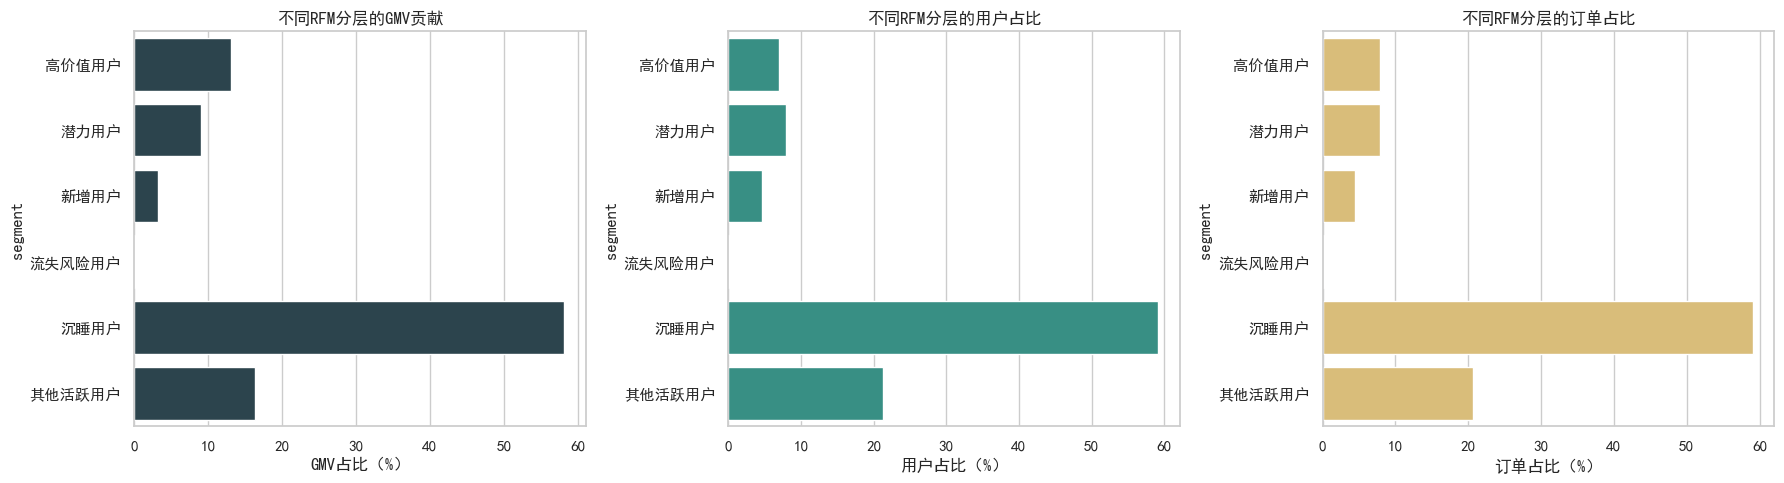

,median_value
recency,219.00
frequency,1.00
monetary,107.78


In [17]:
# 绘制不同RFM分层的用户、订单和GMV贡献
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

sns.barplot(data = segment_summary, 
            x = "gmv_share", 
            y = "segment", 
            ax = axes[0], 
            color = "#264653")
axes[0].set_title("不同RFM分层的GMV贡献")
axes[0].set_xlabel("GMV占比（%）")

sns.barplot(data = segment_summary, 
            x = "user_share", 
            y = "segment", 
            ax = axes[1], 
            color = "#2a9d8f")
axes[1].set_title("不同RFM分层的用户占比")
axes[1].set_xlabel("用户占比（%）")

sns.barplot(data = segment_summary, 
            x = "order_share", 
            y = "segment", 
            ax = axes[2], 
            color = "#e9c46a")
axes[2].set_title("不同RFM分层的订单占比")
axes[2].set_xlabel("订单占比（%）")

plt.tight_layout()
plt.show()
display(rfm[["recency", "frequency", "monetary"]].median().to_frame("median_value"))

In [18]:
# 构造配送时长、延迟天数和是否延迟指标
experience_orders = orders.copy()
experience_orders["delivery_days"] = (experience_orders["order_delivered_customer_date"] - experience_orders["order_purchase_timestamp"]).dt.total_seconds() / 86400
experience_orders["delay_days"] = (experience_orders["order_delivered_customer_date"] - experience_orders["order_estimated_delivery_date"]).dt.total_seconds() / 86400
experience_orders["is_delayed"] = experience_orders["delay_days"] > 0
delivery_summary = pd.DataFrame({"指标": ["平均配送天数", "配送天数中位数", "平均延迟天数", "延迟订单率"],
                                 "数值": [
                                     experience_orders["delivery_days"].mean(),
                                     experience_orders["delivery_days"].median(),
                                     experience_orders["delay_days"].mean(),
                                     experience_orders["is_delayed"].mean() * 100]
                                })
display(delivery_summary)

,指标,数值
0,平均配送天数,12.56
1,配送天数中位数,10.22
2,平均延迟天数,-11.18
3,延迟订单率,8.11


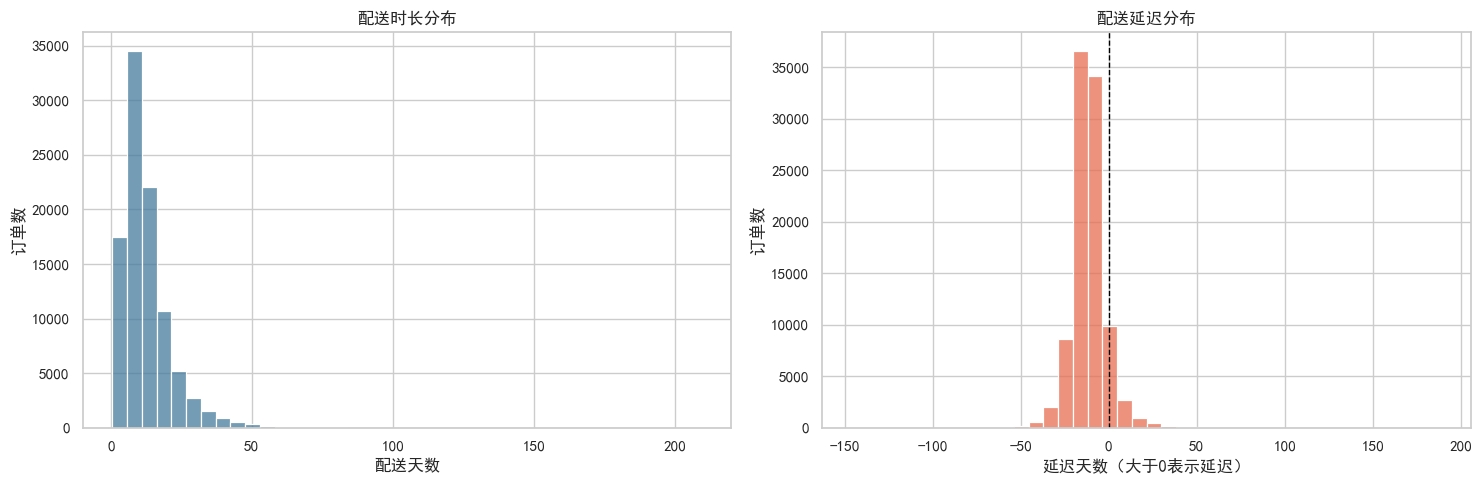

In [19]:
# 绘制配送时长和延迟天数分布
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
sns.histplot(data = experience_orders.dropna(subset = ["delivery_days"]), 
             x = "delivery_days", 
             bins = 40, 
             ax = axes[0], 
             color="#457b9d")
axes[0].set_title("配送时长分布")
axes[0].set_xlabel("配送天数")
axes[0].set_ylabel("订单数")

sns.histplot(data = experience_orders.dropna(subset = ["delay_days"]),
             x = "delay_days", 
             bins = 40, 
             ax = axes[1], 
             color="#e76f51")
axes[1].axvline(0, color = "black", linestyle = '--', linewidth = 1)
axes[1].set_title("配送延迟分布")
axes[1].set_xlabel("延迟天数（大于0表示延迟）")
axes[1].set_ylabel("订单数")
                   
plt.tight_layout()
plt.show()

In [20]:
# 比较配送表现与用户评分的关系
delivery_review = experience_orders.dropna(subset=["delivery_days", "review_score"]).copy()
delivery_review_summary = (delivery_review.groupby("review_score", as_index = False)
                           .agg(
                               orders=("order_id", "nunique"),
                               avg_delivery_days=("delivery_days", "mean"),
                               median_delivery_days=("delivery_days", "median"),
                               delayed_rate=("is_delayed", "mean")
                           )
                          )
spearman_result = delivery_review[["delivery_days", "review_score"]].corr(method = "spearman").iloc[0, 1]
print(f"Spearman相关系数: {spearman_result:.4f}")
display(delivery_review_summary)

Spearman相关系数: -0.2362


,review_score,orders,avg_delivery_days,median_delivery_days,delayed_rate
0,0.00,647,18.69,13.79,0.26
1,1.00,9312,21.34,16.81,0.38
2,1.50,8,17.53,11.68,0.12
3,2.00,2916,16.66,13.27,0.21
4,2.50,30,18.67,14.78,0.20
5,3.00,7915,14.24,12.04,0.11
6,3.30,1,22.03,22.03,0.00
7,3.50,23,13.28,12.15,0.13
8,4.00,18867,12.31,10.79,0.05
9,4.30,1,3.77,3.77,0.00


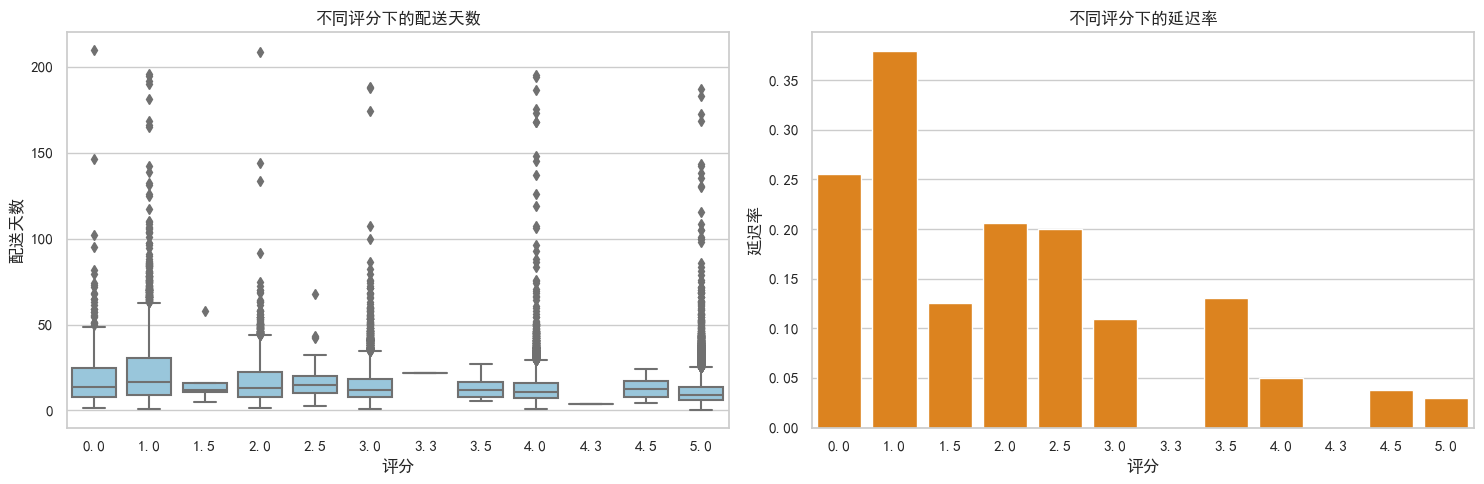

In [21]:
# 绘制不同评分下的配送时长和延迟率
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

sns.boxplot(data = delivery_review, 
            x = "review_score", 
            y = "delivery_days", 
            ax = axes[0], 
            color = "#8ecae6")
axes[0].set_title("不同评分下的配送天数")
axes[0].set_xlabel("评分")
axes[0].set_ylabel("配送天数")

sns.barplot(data = delivery_review_summary, 
            x = "review_score", 
            y = "delayed_rate", 
            ax = axes[1], 
            color = "#fb8500")
axes[1].set_title("不同评分下的延迟率")
axes[1].set_xlabel("评分")
axes[1].set_ylabel("延迟率")

plt.tight_layout()
plt.show()

In [22]:
# 构建品类层面的GMV、配送和评分指标
category_items = items[["order_id", "price", "product_category_name"]].merge(experience_orders[["order_id", "delivery_days", "review_score"]],
                                                                             on = "order_id",
                                                                             how = "left")
category_items["product_category_name"] = category_items["product_category_name"].fillna("unknown")
category_experience = (category_items.groupby("product_category_name", as_index = False)
                       .agg(
                           gmv = ("price", "sum"),
                           orders = ("order_id", "nunique"),
                           avg_delivery_days = ("delivery_days", "mean"),
                           avg_review_score = ("review_score", "mean")).sort_values("gmv", ascending = False))
top_categories = category_experience.head(20)
display(top_categories)

,product_category_name,gmv,orders,avg_delivery_days,avg_review_score
11,beleza_saude,"1,258,681.34",8836,11.98,4.16
66,relogios_presentes,"1,205,005.68",5624,12.66,4.04
13,cama_mesa_banho,"1,036,988.68",9417,12.81,3.88
32,esporte_lazer,"988,048.97",7720,12.15,4.14
44,informatica_acessorios,"911,954.32",6689,13.23,3.97
54,moveis_decoracao,"729,762.49",6449,12.88,3.92
26,cool_stuff,"635,290.85",3632,12.36,4.16
73,utilidades_domesticas,"632,248.66",5884,10.92,4.08
8,automotivo,"592,720.11",3897,12.23,4.08
40,ferramentas_jardim,"485,256.46",3518,13.71,4.06


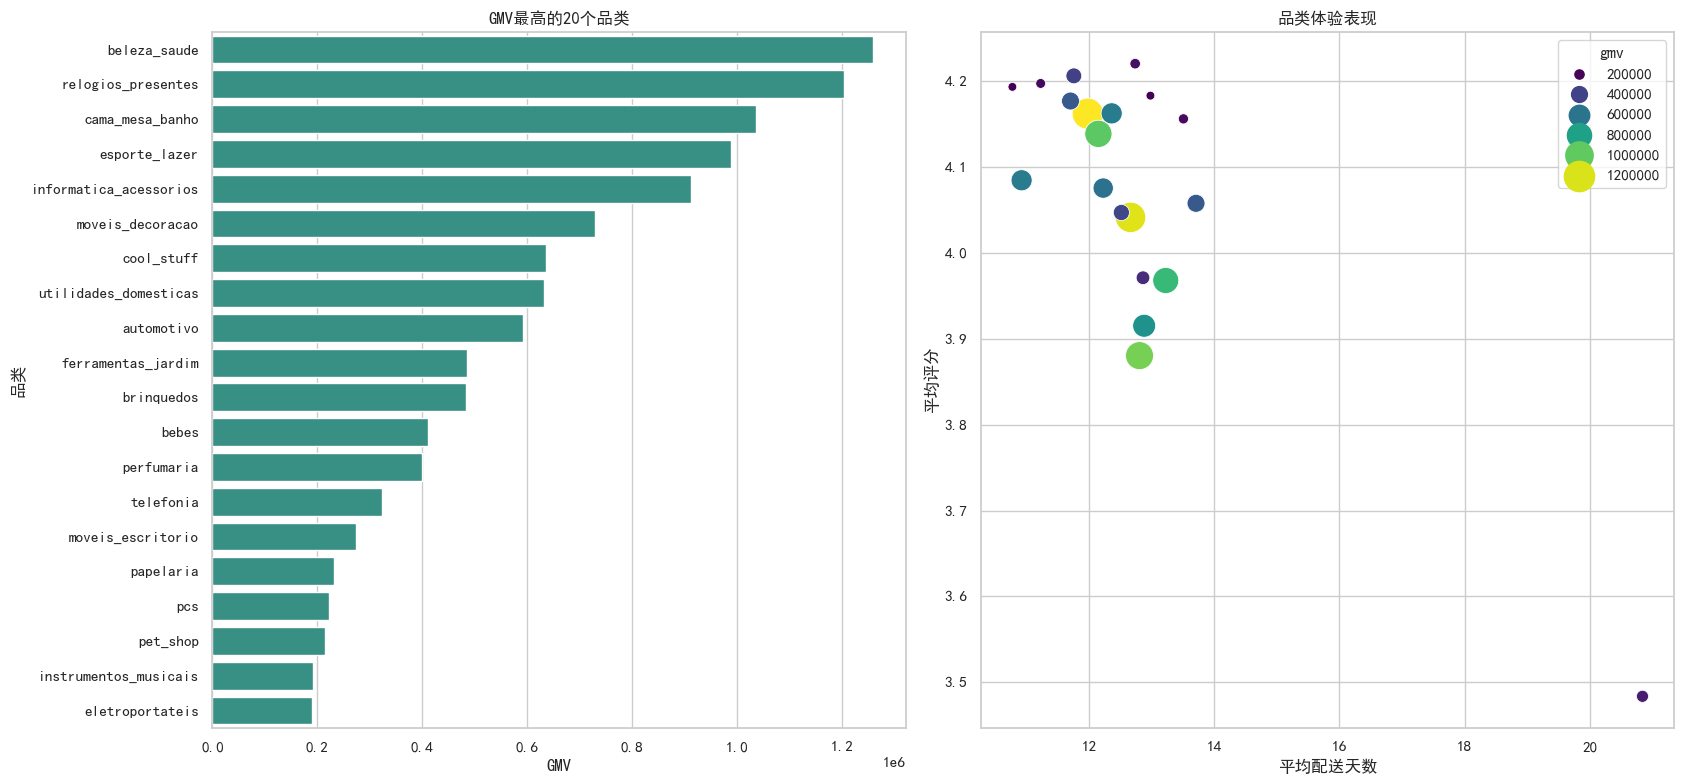

In [23]:
# 可视化高GMV品类的配送和评分表现
fig, axes = plt.subplots(1, 2, figsize = (17, 8))

sns.barplot(data = top_categories, 
            x = "gmv", 
            y = "product_category_name", 
            ax = axes[0], 
            color = "#2a9d8f")
axes[0].set_title("GMV最高的20个品类")
axes[0].set_xlabel("GMV")
axes[0].set_ylabel("品类")

sns.scatterplot(data = top_categories, 
                x = "avg_delivery_days", 
                y = "avg_review_score", 
                size = "gmv", 
                hue = "gmv", 
                sizes = (40, 500), 
                palette = "viridis", 
                ax = axes[1])
axes[1].set_title("品类体验表现")
axes[1].set_xlabel("平均配送天数")
axes[1].set_ylabel("平均评分")

plt.tight_layout()
plt.show()

In [24]:
# 构建卖家层面的GMV、评分、配送和延迟指标
seller_items = items[["order_id", "seller_id", "price"]].merge(experience_orders[["order_id", "delivery_days", "is_delayed", "review_score"]],
                                                               on = "order_id",
                                                               how = "left")
seller_performance = (seller_items.groupby("seller_id", as_index = False)
                      .agg(
                          gmv = ("price", "sum"),
                          orders=('order_id', 'nunique'),
                          avg_review_score=('review_score', 'mean'),
                          delay_rate=('is_delayed', 'mean'),
                          avg_delivery_days=('delivery_days', 'mean')
                      ).query("orders >= 5").dropna(subset = ["gmv", "avg_review_score"])
                     )
display(seller_performance.sort_values("gmv", ascending = False).head(20))

,seller_id,gmv,orders,avg_review_score,delay_rate,avg_delivery_days
857,4869f7a5dfa277a7dca6462dcf3b52b2,"229,472.63",1132,4.11,0.12,15.01
1013,53243585a1d6dc2643021fd1853d8905,"222,776.05",358,4.11,0.04,13.37
881,4a3ca9315b744ce9f8e9374361493884,"200,472.92",1806,3.79,0.11,14.42
3024,fa1c13f2614d7b5c4749cbc52fecda94,"194,042.03",585,4.34,0.10,13.34
1535,7c67e1448b00f6e969d365cea6b010ab,"187,923.89",982,3.33,0.10,22.39
1560,7e93a43ef30c4f03f38b393420bc753a,"176,431.87",336,4.35,0.06,11.34
2643,da8622b14eb17ae2831f4ac5b9dab84a,"160,236.57",1314,4.05,0.07,11.17
1505,7a67c85e85bb2ce8582c35f2203ad736,"141,745.53",1160,4.24,0.06,11.17
192,1025f0e2d44d7041d6cf58b6550e0bfa,"138,968.55",915,3.84,0.09,12.05
1824,955fee9216a65b617aa5c0531780ce60,"135,171.70",1287,4.06,0.08,10.74


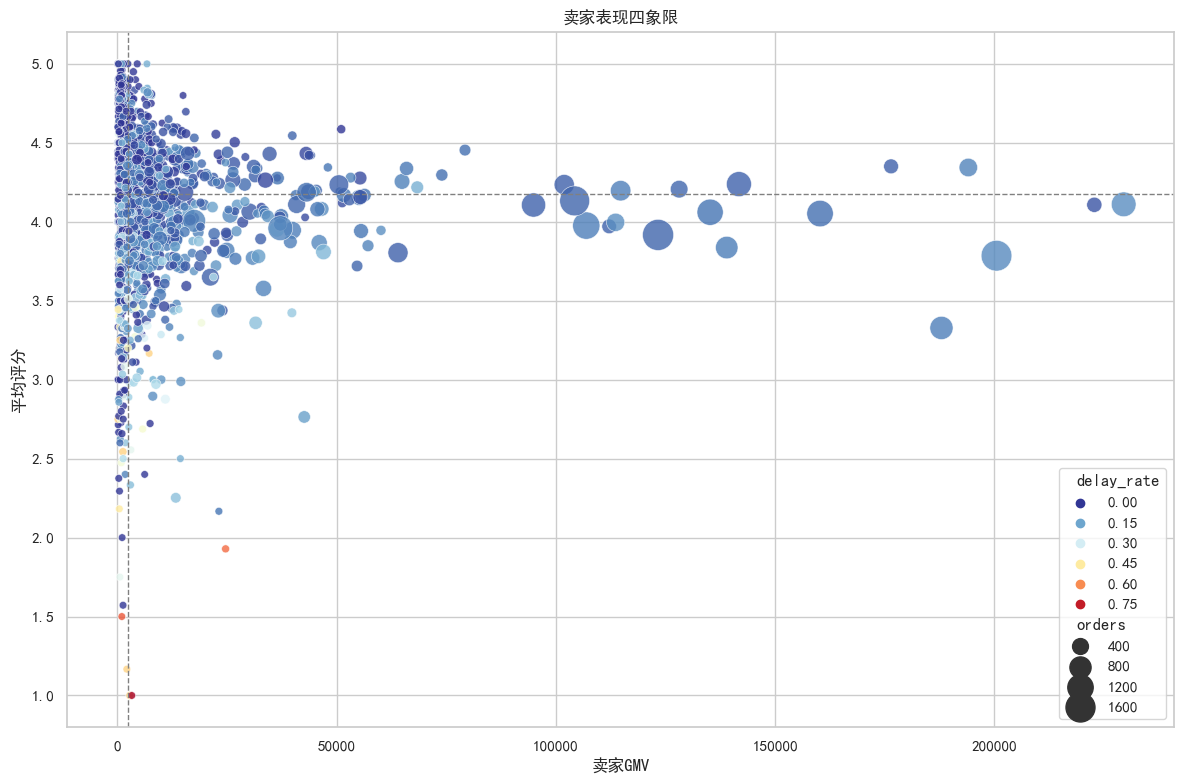

,卖家数量
象限,
高GMV / 低评分,498
低GMV / 高评分,498
高GMV / 高评分,399
低GMV / 低评分,398


In [25]:
# 绘制卖家表现四象限并汇总卖家分组
gmv_median = seller_performance["gmv"].median()
review_median = seller_performance["avg_review_score"].median()
seller_performance["quadrant"] = np.select(
    [
        (seller_performance["gmv"] >= gmv_median) & (seller_performance["avg_review_score"] < review_median),
        (seller_performance["gmv"] >= gmv_median) & (seller_performance["avg_review_score"] >= review_median),
        (seller_performance["gmv"] < gmv_median) & (seller_performance["avg_review_score"] >= review_median)
    ],
    ["高GMV / 低评分", "高GMV / 高评分", "低GMV / 高评分"],
    default="低GMV / 低评分")

plt.figure(figsize = (12, 8))

sns.scatterplot(data = seller_performance, 
                x = "gmv", 
                y = "avg_review_score", 
                size = "orders", 
                hue = "delay_rate", 
                sizes = (30, 500), 
                palette = "RdYlBu_r", 
                alpha = 0.8)
plt.axvline(gmv_median, color = "grey", linestyle = "--", linewidth = 1)
plt.axhline(review_median, color = "grey", linestyle = "--", linewidth = 1)
plt.title("卖家表现四象限")
plt.xlabel("卖家GMV")
plt.ylabel("平均评分")

plt.tight_layout()
plt.show()
display(seller_performance["quadrant"].value_counts().rename_axis("象限").to_frame("卖家数量"))